# 05 — Train All Seeds (VQC, Phase 0-Accepted Configuration)

**Purpose.** Train the VQC once per seed under ideal/noiseless conditions
using the Phase 0-accepted configuration (`single_z` observable,
`RealAmplitudes` `ansatz_reps=4`, `lr=0.05` -- see
`04_phase0_diagnostics.ipynb`). These checkpoints are the fixed models
that noise, adversarial attacks, and mitigation are evaluated against at
*inference time* in the following notebooks (06-09) -- the VQC is not
retrained under each noise/attack condition, per the thesis architecture
(keeps the compute budget tractable given parameter-shift training cost).

**How this was actually run.** Not as a single sequential loop in this
notebook -- full-dataset training at this depth costs ~30-45 min/epoch
even before considering 8 seeds, so the 8 seeds were launched as
**independent parallel OS processes** via `src/experiments/train_seed.py`'s
CLI:

```bash
for seed in 42 43 44 45 46 47 48 49; do
    python -m src.experiments.train_seed --seed $seed --epochs 10 &
done
```

This choice was empirically calibrated first, not assumed: a clean,
uncontended single-process baseline (5.6s/gradient-step) was compared
against 4-way and 8-way concurrent execution on this 16-logical-core
machine, giving ~2.4x and ~3.3x net throughput respectively (diminishing
but positive returns -- see the project's diagnostic log). Running all 8
seeds in parallel (rather than sequentially, or not at all) cut the
sweep from an estimated ~78 hours to the observed ~12 hours.

`epochs=10` (rather than the `20` used in the Phase 0 Step 6f reference
run) was chosen because that run's validation accuracy plateaued by
epoch ~4, with only marginal (~0.6 point) further gains through epoch
16 -- 10 epochs comfortably captures the plateau with margin, at half
the compute cost.

Each seed used its own 80/20 stratified train/val split (`random_state=seed`)
and `StandardScaler` fit on that seed's training split only, with
`train_seed.py` checkpointing the best-val-loss model state after every
epoch (so no progress is lost if a run is interrupted) -- see
`src/experiments/train_seed.py` for the full training loop.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Work\Quantum-Adversarial-Robustness


## Aggregated results (8 seeds)

In [2]:
summary_df = pd.read_csv(PROJECT_ROOT / "results" / "models" / "vqc_all_seeds_summary.csv")
print(summary_df)

print()
print(summary_df[["test_accuracy", "test_precision", "test_recall", "test_f1"]].agg(["mean", "std"]))

   seed  best_val_loss  test_accuracy  test_precision  test_recall   test_f1
0    42       0.639146       0.629229        0.639487     0.697143  0.667072
1    43       0.638086       0.614682        0.626012     0.687619  0.655371
2    44       0.645255       0.617727        0.610641     0.779683  0.684886
3    45       0.639476       0.627199        0.642728     0.676190  0.659035
4    46       0.650432       0.618065        0.624860     0.708571  0.664088
5    47       0.633460       0.628214        0.625263     0.754286  0.683741
6    48       0.652032       0.620771        0.635766     0.674921  0.654758
7    49       0.649172       0.640731        0.645656     0.721905  0.681655

      test_accuracy  test_precision  test_recall   test_f1
mean       0.624577        0.631302      0.71254  0.668826
std        0.008489        0.011688      0.03770  0.012791


**Result:** mean test accuracy 62.46% (std 0.85 points), tightly
clustered across seeds (61.5%-64.1%) -- consistent with the single-seed
reference run (62.9%) from the Phase 0 Step 6f convergence investigation.
This confirms the architecture's ~62-64% ceiling is a reproducible
property of the configuration, not a one-off result from a lucky/unlucky
seed.

## Comparison against the classical baseline (RQ5 preview)

In [3]:
classical_summary = pd.read_json(
    PROJECT_ROOT / "results" / "classical" / "classical_baseline_summary.json"
)

comparison = pd.DataFrame({
    "VQC (single_z, reps=4)": summary_df[["test_accuracy", "test_precision", "test_recall", "test_f1"]]
        .rename(columns=lambda c: c.replace("test_", ""))
        .agg(["mean", "std"]).loc["mean"],
    "VQC std": summary_df[["test_accuracy", "test_precision", "test_recall", "test_f1"]]
        .rename(columns=lambda c: c.replace("test_", ""))
        .agg(["mean", "std"]).loc["std"],
    "Classical baseline": classical_summary.loc["mean"],
    "Classical std": classical_summary.loc["std"],
})
print(comparison)

           VQC (single_z, reps=4)   VQC std  Classical baseline  Classical std
accuracy                 0.624577  0.008489            0.998266       0.000857
precision                0.631302  0.011688            0.998492       0.000470
recall                   0.712540  0.037700            0.998254       0.001722
f1                       0.668826  0.012791            0.998372       0.000807


majority-class baseline accuracy: 0.5328146143437077


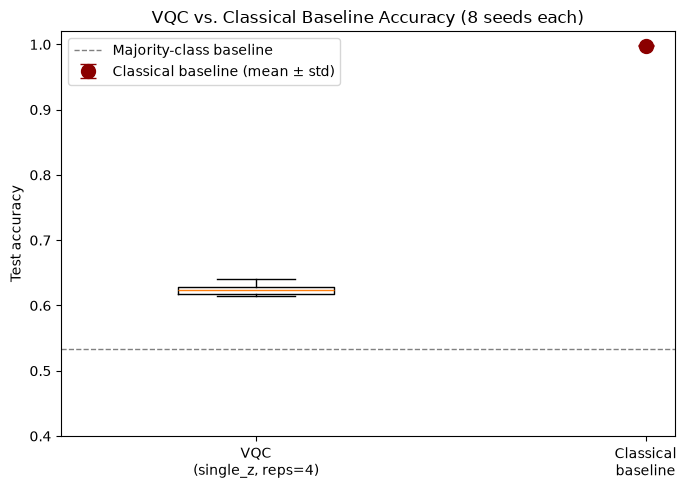

In [4]:
y_test = np.load(PROJECT_ROOT / "data" / "binary" / "y_test.npy")
majority_class_baseline = max(y_test.mean(), 1 - y_test.mean())
print("majority-class baseline accuracy:", majority_class_baseline)

fig, ax = plt.subplots(figsize=(7, 5))

vqc_acc = summary_df["test_accuracy"].values
classical_acc_mean = classical_summary.loc["mean", "accuracy"]
classical_acc_std = classical_summary.loc["std", "accuracy"]

ax.boxplot([vqc_acc], positions=[0], widths=0.4, tick_labels=["VQC\n(single_z, reps=4)"])
ax.errorbar([1], [classical_acc_mean], yerr=[classical_acc_std], fmt="o", markersize=10,
            capsize=6, color="darkred", label="Classical baseline (mean ± std)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["VQC\n(single_z, reps=4)", "Classical\nbaseline"])
ax.set_ylabel("Test accuracy")
ax.set_title("VQC vs. Classical Baseline Accuracy (8 seeds each)")
ax.axhline(majority_class_baseline, color="gray", linestyle="--", linewidth=1, label="Majority-class baseline")
ax.legend()
ax.set_ylim(0.4, 1.02)

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "results" / "models" / "vqc_vs_classical_accuracy.png", dpi=150)
plt.show()

**RQ5 preview:** the classical baseline (99.83% mean accuracy) very
clearly outperforms the VQC (62.46% mean accuracy) on this task -- a
~37 point gap. This is expected and consistent with the Phase 0
investigation's conclusion: this VQC architecture (single feature-map
application, no data re-uploading) has a genuine, bounded expressivity
ceiling well short of what a lightweight classical network achieves
trivially on the same 4 features. The full RQ5 statistical comparison
(paired significance testing across matched seeds) is carried out in
`10_statistical_analysis.ipynb`, once noise and adversarial results are
also available -- this notebook's job is just to establish the clean
(noiseless) baseline both models are compared from.

## Next

`06_noise_models.ipynb` applies depolarizing, phase damping, and readout
noise to these 8 trained checkpoints at inference time.